# Land-use pressure, version 2 — LIST land-use matrix

**Pairs with Stage 5** (`05_landuse_pressure.ipynb`, the DEA-based v1) as the
second of two explicit land-use versions, ported from the `landuse-matrix`
branch into the main pipeline rather than sitting as a separate later-numbered
stage. Everything else in the pipeline (susceptibility, connectivity, catchment
aggregation, 0-1 normalisation) is unchanged -- only the pressure input differs.

**Question:** does replacing the DEA land-cover pressure scores (0, 1, 3) with a
finer land-use matrix, built from the LIST Tasmania land-use polygons (121 classes),
change the risk map?

The matrix scores each class 0-10, anchored to the LIST primary-group hierarchy
(conservation, relatively natural production, dryland agriculture and plantations,
irrigated agriculture, intensive uses) with adjustments inside each group
(see `src/landuse_list.py`). Plantation forestry (LIST code 3.1) is scored **6**,
following Rachel's review that plantation management (spraying, planting, harvest)
warrants more than the originally-scored 5 -- applied here from the
previously-unmerged local stash noted in the handoff.

Sections 1-2 compare LIST 2021 with DEA 2020; section 3 repeats
the comparison against DEA 2021 to remove the one-year offset (it made almost no difference).

**Status:** ported and re-verified against live data this session (sections 1-2,
Mole Creek + statewide LIST-vs-cached-DEA-2020 comparison); section 3's DEA 2021
same-year check re-fetches DEA live and was not re-run here (results below are
from the branch's last run) -- re-run it if DEA pressure for 2021 may have changed.


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_karst_susceptibility, add_connectivity, aggregate_pressure_by_system, rasterize_max
from landuse_list import MATRIX, load_list_landuse, pressure_raster

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"
LIST_2021 = inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp"

SCALINGS = {"matrix": MATRIX}

def corr_both(a, b, valid_mask):
    m1 = valid_mask & ~np.isnan(a) & ~np.isnan(b)
    m2 = m1 & ((a > 0) | (b > 0))
    return np.corrcoef(a[m1], b[m1])[0, 1], np.corrcoef(a[m2], b[m2])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    """Mean risk per named karst area, pooled over polygons sharing a name."""
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

def family(code):
    return ".".join(code.split(".")[:2])

## 1. Mole Creek (25 m)


In [2]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    dea = src.read(1).astype(float); dea_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); transform = src.transform; shape = dem.shape
    bounds = src.bounds; dem_nodata = src.nodata
valid = dem != dem_nodata
karst_cells = intensity > 0
intrinsic = (intensity / 4.0) * (connectivity / 3.0)

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
karst_only = karst_mc[karst_mc["karst_intensity"] > 0]

baseline = np.where(valid, intrinsic * aggregate_pressure_by_system(karst_mc, dea, transform, dea_nodata) / 3.0, np.nan)

lu = load_list_landuse(LIST_2021, "EPSG:7855", bounds_target=tuple(bounds))
print(f"LIST 2021 polygons in the Mole Creek study area: {len(lu)}")

fam = lu.assign(km2=lu.geometry.area / 1e6, family=lu["lu_code"].map(family))
fam["score"] = fam["lu_code"].map(lambda c: __import__("landuse_list").lookup_score(c, MATRIX))
print(fam.groupby(["family", "score"])["km2"].sum().round(1).reset_index().sort_values("km2", ascending=False).head(15).to_string(index=False))

LIST 2021 polygons in the Mole Creek study area: 5767
family  score    km2
   1.1      1 2935.8
   1.2      1 1095.7
   2.2      3  359.8
   3.2      6  301.1
   6.1      0  211.0
   3.1      6  132.0
   1.3      1  116.2
   4.2      8   82.8
   5.4      6   58.0
   4.3      9   27.4
   5.7      6   17.2
   2.1      4   10.8
   3.6      5    5.7
   6.3      0    5.5
   6.2      0    3.3


In [3]:
results_mc = {}
for name, mapping in SCALINGS.items():
    p = pressure_raster(lu, mapping, shape, transform).astype(float)
    top = max(mapping.values())
    eff = aggregate_pressure_by_system(karst_mc, p, transform, -1)
    risk = np.where(valid & (eff >= 0), intrinsic * eff / top, np.nan)
    results_mc[name] = (p, risk)
    r_all, r_nz = corr_both(baseline, risk, valid)
    print(f"{name:11s} vs DEA 2020: all-cells r={r_all:.4f}, nonzero-restricted r={r_nz:.4f}")

print("\nTop named areas")
print("DEA 2020 baseline:")
print(named_ranking(baseline, karst_only, shape, transform, valid).head(7).to_string(index=False))
for name in SCALINGS:
    print(f"\nLIST {name}:")
    print(named_ranking(results_mc[name][1], karst_only, shape, transform, valid).head(7).to_string(index=False))

matrix      vs DEA 2020: all-cells r=0.9988, nonzero-restricted r=0.9899

Top named areas
DEA 2020 baseline:
                                KNAME  mean_risk   n_px
         Mole Creek  (Chudleigh Hill)   0.483904    214
                           Mole Creek   0.339472 388198
                              Lorinna   0.275307    658
Stockers Plain (Muddy Ck; Golden Vly)   0.263436    539
              Meander - Western Creek   0.143417  24111
                         Quamby Brook   0.105381   1338
                        Golden Valley   0.091044   2075

LIST matrix:
                                KNAME  mean_risk   n_px
         Mole Creek  (Chudleigh Hill)   0.398442    214
                              Lorinna   0.273918    658
Stockers Plain (Muddy Ck; Golden Vly)   0.263689    539
                           Mole Creek   0.217468 388198
              Meander - Western Creek   0.122175  24111
                        Golden Valley   0.097602   2075
                         Quamby Brook

In [4]:
p_matrix = results_mc["matrix"][0]
sel = karst_cells & valid & (dea != dea_nodata) & (p_matrix >= 0)
ct = pd.crosstab(pd.Series(dea[sel], name="DEA score (0/1/3)"), pd.Series(p_matrix[sel], name="LIST matrix score"), normalize="index").round(3) * 100
print("On karst cells: where each DEA class lands in the LIST matrix (% of row)")
print(ct.to_string())

On karst cells: where each DEA class lands in the LIST matrix (% of row)
LIST matrix score  0.0   1.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0
DEA score (0/1/3)                                                            
0.0                75.1   7.1   0.2   0.0   0.0   9.5   1.7   6.5   0.0   0.0
1.0                 1.1  46.2   4.6   1.1   1.0  37.7   0.5   7.5   0.3   0.0
3.0                 0.2   1.6   0.1   0.1   0.4  67.4   0.9  28.1   1.1   0.1


## 2. Statewide (100 m)


In [5]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tshape = (src.height, src.width); ttransform = src.transform; tnodata = src.nodata
    tbase = src.read(1).astype(float)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata
tbase = np.where(tvalid, tbase, np.nan)

karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform)
t_con = rasterize_max(karst_tas, "connectivity", tshape, ttransform)
tintrinsic = (t_int.astype(float) / 4.0) * (t_con.astype(float) / 3.0)
tkarst = t_int > 0
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

lu_t = load_list_landuse(LIST_2021, "EPSG:7855")
print(f"LIST 2021 polygons statewide: {len(lu_t)}")

results_t = {}
for name, mapping in SCALINGS.items():
    p = pressure_raster(lu_t, mapping, tshape, ttransform).astype(float)
    top = max(mapping.values())
    eff = aggregate_pressure_by_system(karst_tas, p, ttransform, -1)
    risk = np.where(tvalid & (eff >= 0), tintrinsic * eff / top, np.nan)
    results_t[name] = (p, risk)
    r_all, r_nz = corr_both(tbase, risk, tvalid)
    print(f"{name:11s} vs DEA 2020: all-cells r={r_all:.4f}, nonzero-restricted r={r_nz:.4f}")

LIST 2021 polygons statewide: 138337


matrix      vs DEA 2020: all-cells r=0.9468, nonzero-restricted r=0.8563


In [6]:
print("Top 10 named areas statewide")
print("\nDEA 2020 baseline:")
base_rank = named_ranking(tbase, tkarst_only, tshape, ttransform, tvalid)
print(base_rank.head(10).to_string(index=False))
mat_rank = named_ranking(results_t["matrix"][1], tkarst_only, tshape, ttransform, tvalid)
print("\nLIST matrix:")
print(mat_rank.head(10).to_string(index=False))

j = base_rank.merge(mat_rank, on="KNAME", suffixes=("_dea", "_list"))
j = j[(j.n_px_dea >= 20)]
from scipy.stats import spearmanr
rho = spearmanr(j.mean_risk_dea, j.mean_risk_list, nan_policy="omit")[0]
print(f"\nSpearman rank correlation of named-area mean risk, DEA vs LIST matrix (areas with >= 20 px, n={len(j)}): {rho:.3f}")
print(f"Mean risk on karst cells: DEA {np.nanmean(tbase[tkarst & tvalid]):.4f}, LIST matrix {np.nanmean(results_t['matrix'][1][tkarst & tvalid]):.4f}")

Top 10 named areas statewide

DEA 2020 baseline:


                         KNAME  mean_risk  n_px
Welcome River (1) / Port Hills   0.750000     2
                  Vinegar Hill   0.750000     9
            Emita - Memana (2)   0.694615  7502
                 Doctors Rocks   0.647665    71
   Irishtown - Sedgy Creek (2)   0.634849   106
                  Grim-Trefoil   0.625000    11
   Irishtown - Sedgy Creek (3)   0.613636    11
                 Flowery Gully   0.577099   120
                    Port Hills   0.571429    57
              Mt Stanley Creek   0.552826    14



LIST matrix:
                         KNAME  mean_risk  n_px
                 Doctors Rocks   0.536744    71
                 Flowery Gully   0.525191   120
   Irishtown - Sedgy Creek (2)   0.517273   106
             Savage River Mine   0.490385    26
Welcome River (1) / Port Hills   0.450000     2
                  Vinegar Hill   0.450000     9
                      Puncheon   0.437288   132
                    Port Hills   0.432622    57
                   McRae Hills   0.426724    16
            Emita - Memana (2)   0.410051  7502



Spearman rank correlation of named-area mean risk, DEA vs LIST matrix (areas with >= 20 px, n=260): 0.734
Mean risk on karst cells: DEA 0.2438, LIST matrix 0.1297


Share of karst cells by LIST matrix score (statewide, 2021):
0      1.8
1     66.0
3      9.3
4      0.2
5      0.3
6     15.5
7      0.4
8      6.4
9      0.2
10     0.0


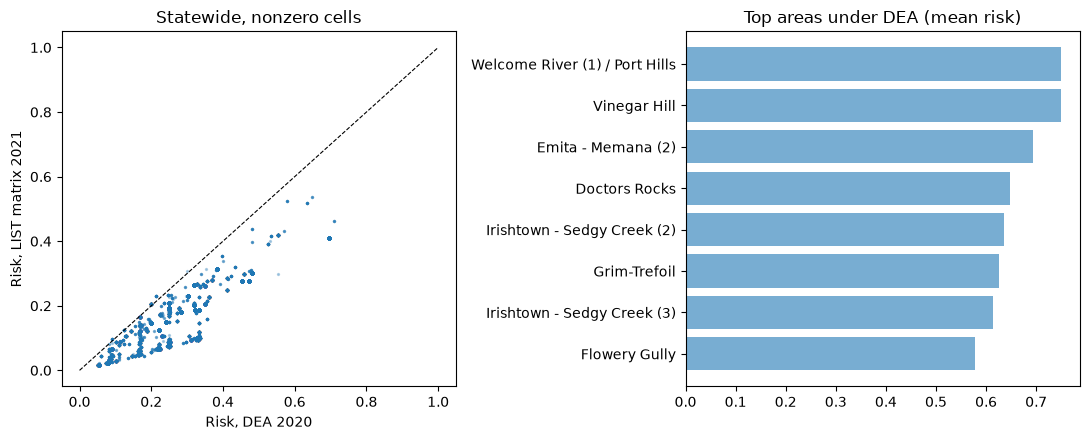

In [7]:
p_t = results_t["matrix"][0]
sel = tkarst & tvalid & (p_t >= 0)
fam_codes = pd.Series(p_t[sel]).round(0).astype(int)
print("Share of karst cells by LIST matrix score (statewide, 2021):")
print((fam_codes.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
m = tvalid & ~np.isnan(results_t["matrix"][1]) & ((tbase > 0) | (results_t["matrix"][1] > 0))
idx = np.random.default_rng(0).choice(np.flatnonzero(m.ravel()), size=min(20000, int(m.sum())), replace=False)
ax[0].scatter(tbase.ravel()[idx], results_t["matrix"][1].ravel()[idx], s=2, alpha=0.3)
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[0].set_xlabel("Risk, DEA 2020"); ax[0].set_ylabel("Risk, LIST matrix 2021"); ax[0].set_title("Statewide, nonzero cells")
ax[1].barh(base_rank.head(8)["KNAME"][::-1], base_rank.head(8)["mean_risk"][::-1], alpha=0.6, label="DEA")
ax[1].set_title("Top areas under DEA (mean risk)")
plt.tight_layout(); plt.show()

## 3. Same-year check: DEA 2021 vs LIST 2021

The comparisons above set LIST 2021 against DEA 2020. DEA also covers 2021, so this removes the one-year offset. DEA 2020 vs DEA 2021 is shown as a reference for how much the pressure layer moves in a single year.

In [8]:
sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure

mc_box = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").to_crs("EPSG:4326").total_bounds.tolist()
tas_box = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg").to_crs("EPSG:4326").total_bounds.tolist()

# Mole Creek
dea21 = fetch_landuse_pressure(mc_box, 2021, outpath / "dem_mc_EPSG7855.tif").astype(float)
base21 = np.where(valid & (dea21 != 255), intrinsic * aggregate_pressure_by_system(karst_mc, dea21, transform, 255) / 3.0, np.nan)
print("MOLE CREEK (nonzero-restricted r | all-cells r)")
for label, a, b in [("DEA 2020 vs DEA 2021", baseline, base21),
                    ("LIST matrix 2021 vs DEA 2021", base21, results_mc["matrix"][1])]:
    r_all, r_nz = corr_both(a, b, valid)
    print(f"  {label:34s} {r_nz:.4f} | {r_all:.4f}")
print("\nTop named areas, DEA 2021:")
print(named_ranking(base21, karst_only, shape, transform, valid).head(5).to_string(index=False))

MOLE CREEK (nonzero-restricted r | all-cells r)
  DEA 2020 vs DEA 2021               0.9995 | 1.0000
  LIST matrix 2021 vs DEA 2021       0.9909 | 0.9989

Top named areas, DEA 2021:
                                KNAME  mean_risk   n_px
         Mole Creek  (Chudleigh Hill)   0.571132    214
                           Mole Creek   0.328433 388198
Stockers Plain (Muddy Ck; Golden Vly)   0.287125    539
                              Lorinna   0.266708    658
              Meander - Western Creek   0.136902  24111


In [9]:
# Statewide
dea21_t = fetch_landuse_pressure(tas_box, 2021, outpath / "dem_tas_100m_EPSG7855.tif", target_crs="EPSG:7855").astype(float)
base21_t = np.where(tvalid & (dea21_t != 255), tintrinsic * aggregate_pressure_by_system(karst_tas, dea21_t, ttransform, 255) / 3.0, np.nan)
print("STATEWIDE (nonzero-restricted r | all-cells r)")
for label, a, b in [("DEA 2020 vs DEA 2021", tbase, base21_t),
                    ("LIST matrix 2021 vs DEA 2021", base21_t, results_t["matrix"][1])]:
    r_all, r_nz = corr_both(a, b, tvalid)
    print(f"  {label:34s} {r_nz:.4f} | {r_all:.4f}")

rank21 = named_ranking(base21_t, tkarst_only, tshape, ttransform, tvalid)
j = rank21.merge(mat_rank, on="KNAME", suffixes=("_dea", "_list"))
j = j[j.n_px_dea >= 20]
print(f"\nSpearman rank correlation of named-area mean risk, DEA 2021 vs LIST matrix 2021 (n={len(j)}): {spearmanr(j.mean_risk_dea, j.mean_risk_list, nan_policy='omit')[0]:.3f}")
print("\nTop 10 named areas, DEA 2021:")
print(rank21.head(10).to_string(index=False))
print(f"\nMean risk on karst cells: DEA 2021 {np.nanmean(base21_t[tkarst & tvalid]):.4f}, LIST matrix {np.nanmean(results_t['matrix'][1][tkarst & tvalid]):.4f}")

STATEWIDE (nonzero-restricted r | all-cells r)
  DEA 2020 vs DEA 2021               0.9962 | 0.9992
  LIST matrix 2021 vs DEA 2021       0.8619 | 0.9484



Spearman rank correlation of named-area mean risk, DEA 2021 vs LIST matrix 2021 (n=260): 0.737

Top 10 named areas, DEA 2021:
                       KNAME  mean_risk  n_px
                Vinegar Hill   0.750000     9
          Emita - Memana (2)   0.674554  7502
 Irishtown - Sedgy Creek (2)   0.672727   106
 Irishtown - Sedgy Creek (3)   0.659091    11
               Doctors Rocks   0.649725    71
Mole Creek  (Chudleigh Hill)   0.632479    13
                  Port Hills   0.598571    57
               Flowery Gully   0.544020   120
              Whistler-Porky   0.506538  6070
        Fairview (Redpa) (2)   0.493947   207

Mean risk on karst cells: DEA 2021 0.2430, LIST matrix 0.1297


## Results (LIST matrix 2021 vs DEA)

Correlations compare the final risk maps (intrinsic vulnerability x aggregated pressure), so the shared susceptibility and connectivity layers inflate them.

**Mole Creek: the matrix barely changes the picture.** Nonzero-cell r = 0.99 against DEA 2020 and 2021. The main "Mole Creek" system drops from 2nd to 4th behind Lorinna and Stockers Plain, because much of it is natural cover that now scores low relative to pasture.

**Statewide: it changes more.** Nonzero-cell r = 0.86 against both DEA 2020 and DEA 2021. Across 260 named areas (at least 20 pixels each) the rank correlation is 0.74. Emita-Memana falls from 3rd to 10th, and mining (Savage River Mine) enters the top four, which DEA could not see.

**Same-year check:** DEA 2020 vs DEA 2021 correlate at 0.9995 (Mole Creek) and 0.996 (statewide), so the one-year offset does not explain the differences; they come from the data source and scoring. Single-year DEA values on very small areas are noisy (Chudleigh Hill, 214 pixels, moves from 0.48 to 0.57).

**What DEA was hiding, on Mole Creek karst cells:**
- 28% of cells DEA calls "natural vegetation" are modified pasture in LIST, 10.5% are plantation, and 4.6% are native production forest.
- Of DEA's "cultivated" cells, 66% are modified pasture (score 6) and 28% irrigated pasture (score 8).
- Plantation forestry covers 132 km2 of the Mole Creek study area, against 301 km2 of modified pasture.

**Caution on absolute levels.** Mean statewide karst risk roughly halves (0.243 DEA 2021 to 0.130 matrix) because natural land scores 1/10 here against 1/3 in the DEA scheme. Correlations are unaffected, but the fixed 0.2-wide risk classes would not be comparable. If adopted, the natural anchor needs setting deliberately.
